### Paper Analysis Notebook - Figures

This notebook is for plotting some of the figures in the paper and interpreting the results of the model simulation.

Prerequisites:
    
    -  to run this notebook you need to have first run "full_simulatyion.ipynb

In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##### 1. User Config

In [2]:
# Some constant parameters
total_capstock = 1.629*1e12 # 1.6 trillion USD according to GIRI
baseline_rating = 12.42 # this is what model predicts with no GDP losses (actual S&P rating is 13)

##### 2. Load and prepare data

In [3]:
root = Path.cwd().parent.parent # find project root
# Load results
df = pd.read_csv(os.path.join(root, 'outputs', 'results', 'full_model_simulation.csv'))
# Add total cap damage column
df["CAP_dam"] = df[["PRI_dam", "PUB_dam"]].sum(axis=1)
# Add downgrade column
df["Downgrade"] = baseline_rating - df["predicted_rating"]

##### 3. Define common functions

In [4]:
# Functions for extracting future scenarios
def get_sorted_series(df, scenario, epoch, stat, adaptation, col):
    d = df[
        (df["scenario"].eq(scenario)) &
        (df["adaptation"].eq(adaptation)) &
        ((df["epoch"].eq(epoch)) if epoch is not None else df["epoch"].isna()) &
        ((df["stat"].eq(stat)) if stat is not None else df["stat"].isna())
    ][[col]].copy()

    d = d.sort_values(col, ascending=False).reset_index(drop=True)
    return d[col].to_numpy()

#### Figure 4 - Full model chain outputs (baseline scenario)

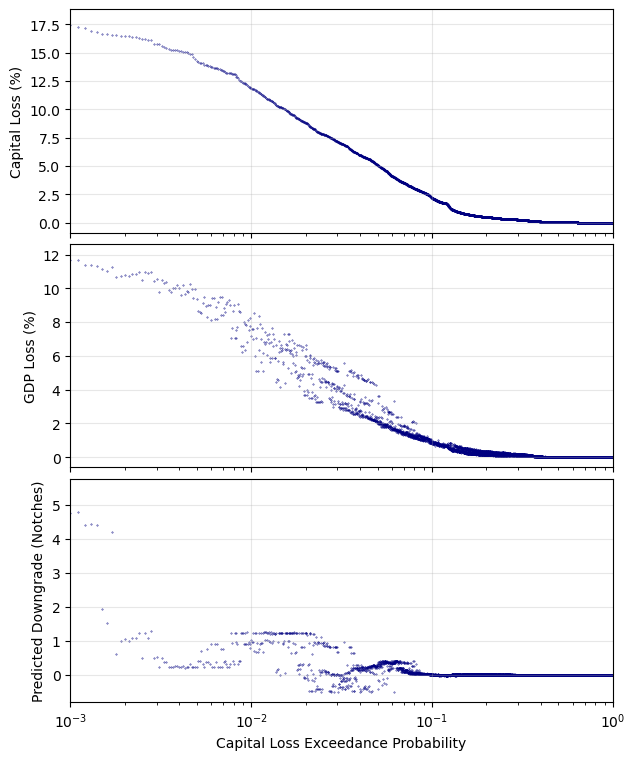

In [5]:
order_col = "CAP_dam" # what metric do we want to order losses by?
plot_col = 'navy'
figure_4 = df[
    (df['scenario'] == 'baseline') &
    (df['adaptation'] == False)
    ]
# Sort on order col
figure_4_sorted = figure_4.sort_values(by=order_col, ascending=False).reset_index(drop=True)
figure_4_sorted['order'] = np.arange(len(figure_4_sorted))
# Extract data to plot
year_index = figure_4_sorted['year_index'].to_numpy()
cap_series = figure_4_sorted['CAP_dam'].to_numpy()
gdp_series = figure_4_sorted['gdp_loss'].to_numpy()
rat_series = figure_4_sorted['Downgrade'].to_numpy()
x = np.arange(1, len(cap_series)+1) / (len(cap_series)+1) # x values for plot

# Plot figure
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(7,9),
    sharex=True
)
axes[0].scatter(x, (cap_series/total_capstock)*100, s=0.1, color=plot_col)
axes[0].set_ylabel("Capital Loss (%)")
axes[0].set_xscale("log")
axes[1].scatter(x, gdp_series*-1, s=0.1, color=plot_col)
axes[1].set_ylabel("GDP Loss (%)")
axes[2].scatter(x, rat_series, s=0.1, color=plot_col)
axes[2].set_ylabel("Predicted Downgrade (Notches)")
axes[2].set_xlabel("Capital Loss Exceedance Probability") # All ordered on cap loss so just use this X label once at bottom

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.001, 1)

plt.subplots_adjust(hspace=0.05) # adjust spacing

plt.show()

### Figure 5 - Downgrade probabilities over time

C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_16836\1812087720.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  downgrades


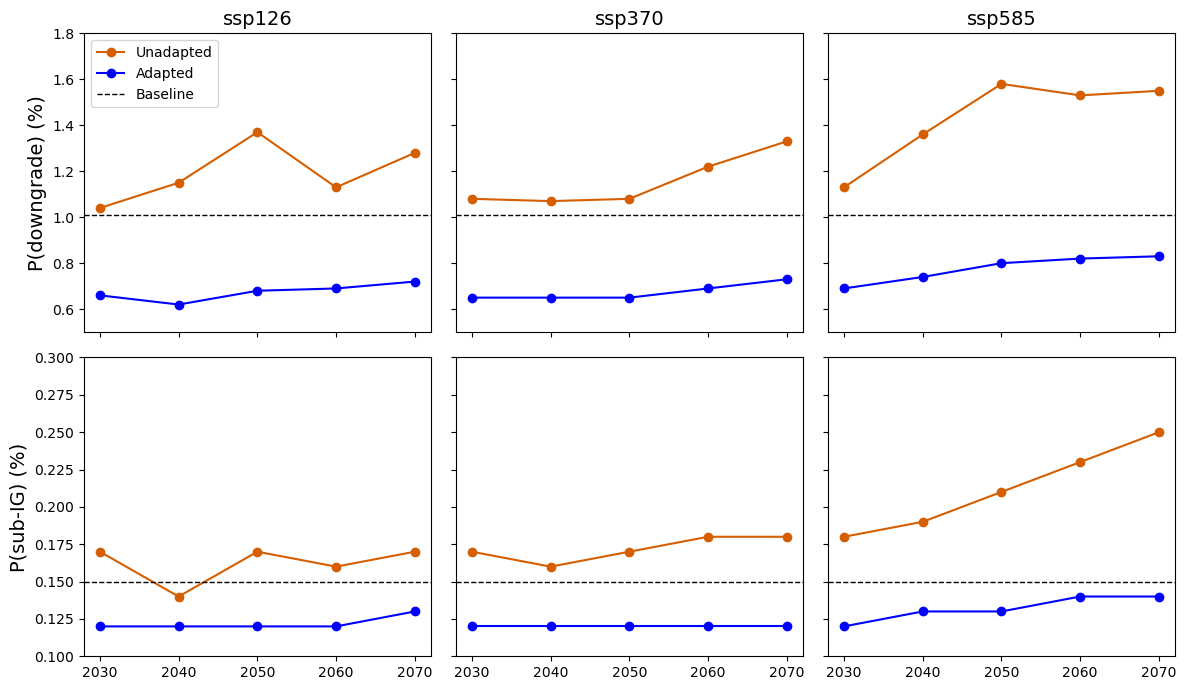

In [6]:
### Run some calcs to calculate downgrade 
# Figure information 
stat = 'mean' # how to sample future ensemble spread, options: q95, q05, q50, mean
epochs = [2030, 2040, 2050, 2060, 2070] # epochs to plot
scenarios = ['ssp126', 'ssp370', 'ssp585'] # scenarios to plot
adaptation_vals = [True, False] # adaptation scenarios to plot
mask_future = (
    (df['stat'].eq(stat)) &
    (df['epoch'].isin(epochs)) &
    (df['scenario'].isin(scenarios)) & 
    (df['adaptation'].isin(adaptation_vals))
    
)
mask_baseline = df['scenario'].eq('baseline') & df['adaptation'].eq(False)
downgrades = df.loc[mask_future | mask_baseline].copy()

downgrades = downgrades[['scenario', 'epoch', 'Downgrade', 'year_index', 'adaptation']]

def downgrade_stats(group):
    x = group["Downgrade"]
    return pd.Series({
        "P_1plus": (x >= 1).mean() * 100, # probability of at least a 1 notch downgrade
        "P_3plus": (x >= 3).mean() * 100, # probability of a 3 notch downgrade or worse (sub-investment grade downgtade)
    })

summary = (
    downgrades
    .groupby(["scenario", "epoch", "adaptation"], dropna=False)
    .apply(downgrade_stats)
    .reset_index()
)

dfp = summary.copy()

plot_vars = ["P_1plus" , "P_3plus"] # which variables are we plotting

# split baseline vs futures
base = dfp[dfp["scenario"].eq("baseline")].copy()
fut  = dfp[dfp["scenario"].ne("baseline")].copy()
fut["epoch"] = fut["epoch"].astype(int)


fig, axes = plt.subplots(2, 3, figsize=(12,7), sharex=True)

for row, var in enumerate(plot_vars):
    for col, sc in enumerate(scenarios):

        ax = axes[row, col]
        d = fut[fut["scenario"].eq(sc)].sort_values("epoch")

        for ad in [False,True]:
            dd = d[d["adaptation"].eq(ad)]
            
            if ad == True:
                color = "blue"
                label = "Adapted"
            if ad == False:
                color = "#D55E00"
                label = "Unadapted"

            ax.plot(
                dd["epoch"],
                dd[var] if "P_" in var else dd[var],
                marker="o",
                color=color,
                label=label
            )

        # baseline line
        b = base[base["adaptation"].eq(False)][var].iloc[0]
        b = b if "P_" in var else b
        ax.axhline(b, linestyle="--", linewidth=1, color='k', label='Baseline')

        if row == 0:
            ax.set_title(sc, size=14)

        if col == 0 and row ==0:
            ax.set_ylabel("P(downgrade) (%)" if "P_" in var else var, size=14)

        if col == 0 and row ==1:
            ax.set_ylabel("P(sub-IG) (%)" if "P_" in var else var, size=14)

        # if row == 1:
        #     ax.set_xlabel("Year", size=12)

        # Hide Y labels
        if col != 0:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)

# single legend
axes[0,0].legend(loc="upper left", bbox_to_anchor=(0,1))

# Set axes sizes
for ax in axes[0]: ax.set_ylim(0.5, 1.8)   # top row
for ax in axes[1]: ax.set_ylim(0.1, 0.3)  # bottom row 


plt.tight_layout()
plt.show()

### Figure X - Future Losses

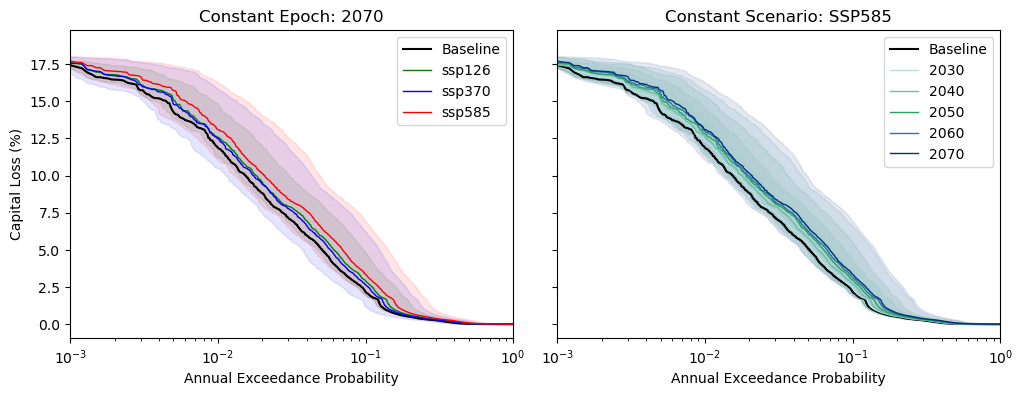

In [7]:
# Figure parameters
order_col = 'CAP_dam'
# Left figure (scenario settings)
s_year = 2070
scenarios = ["ssp126", "ssp370", "ssp585"]
s_colors = ['green', 'blue', 'red']
# Right figure (epoch settings)
e_scenario = 'ssp585'
epochs = [2030, 2040, 2050, 2060, 2070]
e_colors = ['#b2e2e2', '#66c2a4', '#2ca25f', '#1f78b4', '#08306b']

baseline_series = get_sorted_series(df, "baseline", epoch=None, stat=None, adaptation=False, col=order_col) / total_capstock*100

n = len(baseline_series)
x = np.arange(1, n+1) / (n+1)  # exceedance probability

fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

# Plot left figure (Difference in scenarios)
axes[0].plot(x, baseline_series, color="black", label="Baseline")
for idx, sc in enumerate(scenarios):
    low  = get_sorted_series(df, sc, s_year, "q05", False, col=order_col) / total_capstock*100
    mean = get_sorted_series(df, sc, s_year, "mean", False, col=order_col) / total_capstock*100
    high = get_sorted_series(df, sc, s_year, "q95", False, col=order_col) / total_capstock*100

    axes[0].plot(x, mean, lw=1, label=f"{sc}", color=s_colors[idx])
    axes[0].fill_between(x, low, high, alpha=0.1, color=s_colors[idx])

# Plot right figure (Difference across epochs)
axes[1].plot(x, baseline_series, color="black", label="Baseline")
for idx, sc in enumerate(epochs):
    low  = get_sorted_series(df, e_scenario, sc, "q05", False, col=order_col) / total_capstock*100
    mean = get_sorted_series(df, e_scenario, sc, "mean", False, col=order_col) / total_capstock*100
    high = get_sorted_series(df, e_scenario, sc, "q95", False, col=order_col) / total_capstock*100

    axes[1].plot(x, mean, lw=1, label=f"{sc}", color=e_colors[idx])
    axes[1].fill_between(x, low, high, alpha=0.1, color=e_colors[idx])



axes[0].set_xscale("log")
axes[0].set_xlim(0.001, 1)
axes[0].legend()
axes[0].set_ylabel('Capital Loss (%)')
axes[0].set_xlabel('Annual Exceedance Probability')
axes[0].set_title('Constant Epoch: 2070')
axes[1].set_xscale("log")
axes[1].set_xlim(0.001, 1)
axes[1].legend()
axes[1].set_xlabel('Annual Exceedance Probability')
axes[1].set_title('Constant Scenario: SSP585')
fig.subplots_adjust(wspace=0.1)

### Figure X - Benefits of Adaptation

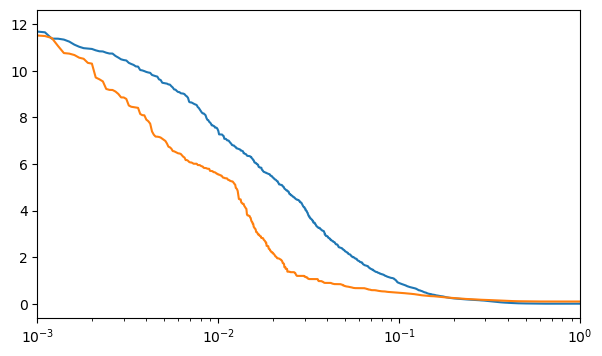

In [10]:
order_col = 'gdp_loss'
baseline_series = get_sorted_series(df, "baseline", epoch=None, stat=None, adaptation=False, col=order_col)[::-1]*-1
adapted_series = get_sorted_series(df, "baseline", epoch=None, stat=None, adaptation=True, col=order_col)[::-1]*-1
n = len(baseline_series)
x = np.arange(1, n+1) / (n+1)  # exceedance probability
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(x, baseline_series)
ax.plot(x, adapted_series)
ax.set_xlim(0.001, 1)
ax.set_xscale("log")

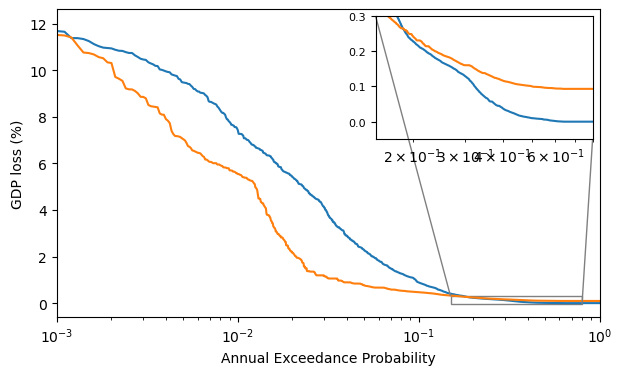

In [9]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

order_col = 'gdp_loss'
baseline_series = get_sorted_series(df, "baseline", epoch=None, stat=None, adaptation=False, col=order_col)[::-1]*-1
adapted_series = get_sorted_series(df, "baseline", epoch=None, stat=None, adaptation=True, col=order_col)[::-1]*-1

n = len(baseline_series)
x = np.arange(1, n+1) / (n+1)

fig, ax = plt.subplots(figsize=(7,4))

ax.plot(x, baseline_series, label="Baseline")
ax.plot(x, adapted_series, label="Adapted")

ax.set_xlim(0.001, 1)
ax.set_xscale("log")
ax.set_ylabel("GDP loss (%)")
ax.set_xlabel("Annual Exceedance Probability")

# --- ZOOM INSET ---
axins = inset_axes(ax, width="40%", height="40%", loc="upper right")

axins.plot(x, baseline_series)
axins.plot(x, adapted_series)

axins.set_xlim(0.15, 0.8)
axins.set_ylim(-0.05, 0.3)
axins.set_xscale("log")

# Optional: cleaner inset look
axins.tick_params(labelsize=8)

# Draw connecting box
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.show()

In [105]:
adapted_series

array([  0.        ,   0.        ,   0.        , ..., -11.83921621,
       -11.85909829, -11.86979681])